In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('archive/amz_uk_price_prediction_dataset.csv')


In [2]:
crosstab_df = pd.crosstab(df['category'], df['isBestSeller'])
print(crosstab_df.head(10))



isBestSeller                       False  True 
category                                       
3D Printers                          247      1
3D Printing & Scanning              4065      2
Abrasive & Finishing Products        245      5
Action Cameras                      1696      1
Adapters                             251      3
Agricultural Equipment & Supplies   8421    109
Alexa Built-In Devices               106      1
Art & Craft Supplies                 253      5
Arts & Crafts                       9319    230
Baby                               14709    341


## Are there categories where being a best-seller is more prevalent?

In [7]:
proportions = crosstab_df.div(crosstab_df.sum(axis=1), axis=0)
best_seller_trends = proportions[True].sort_values(ascending=False)
# print(best_seller_trends.head(10))
# if best_seller_trends.values >= 0.05:
#     print("")

top_categories = best_seller_trends[best_seller_trends >= 0.05]
print(top_categories)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Name: True, dtype: float64


## Statistical Tests:

## Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.

In [8]:
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, ex = chi2_contingency(crosstab_df)


In [11]:
total_products = crosstab_df.sum().sum()
number_of_options = min(crosstab_df.shape) - 1
v_score = np.sqrt(chi2 / (total_products * number_of_options))

print(f"is random? (P-value): {p}") 
print(f"how strong does CATEGORY affect best-seller status? (0-1 scale): {v_score}")

is random? (P-value): 0.0
how strong does CATEGORY affect best-seller status? (0-1 scale): 0.1222829439760564


## Compute Cramér's V to understand the strength of association between best-seller status and category.

In [12]:
top_10_categories = df['category'].value_counts().nlargest(10).index
plot_data = proportions.loc[top_10_categories]

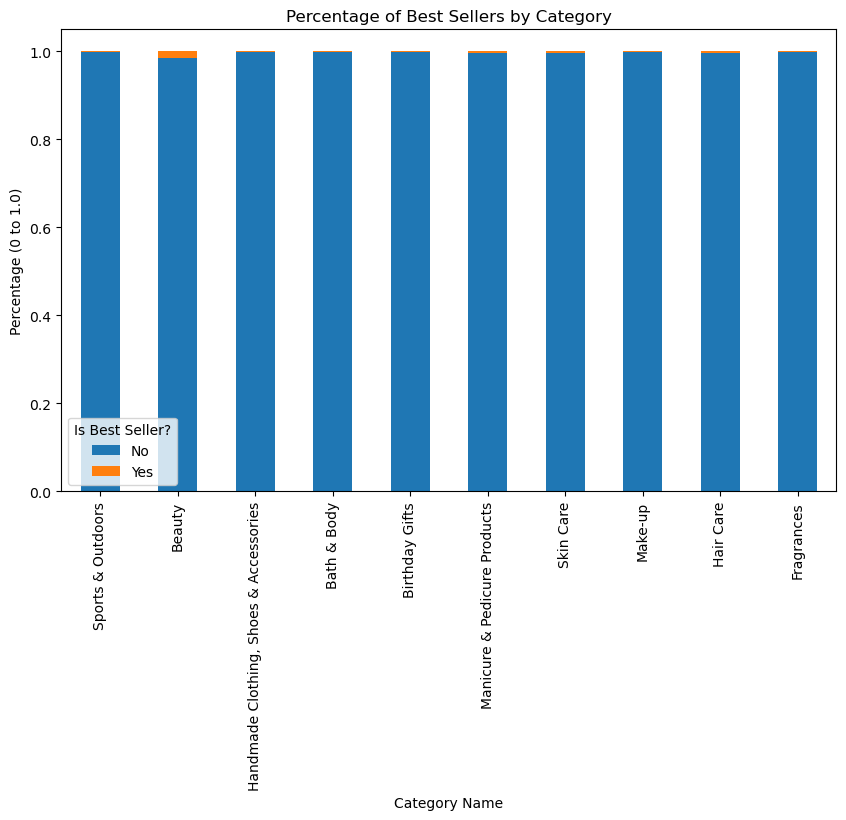

In [13]:
plot_data.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Percentage of Best Sellers by Category')
plt.xlabel('Category Name')
plt.ylabel('Percentage (0 to 1.0)')
plt.legend(title='Is Best Seller?', labels=['No', 'Yes'])
plt.show()

## visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [14]:
top_10_index = df['category'].value_counts().nlargest(10).index
plot_data = proportions.loc[top_10_index]

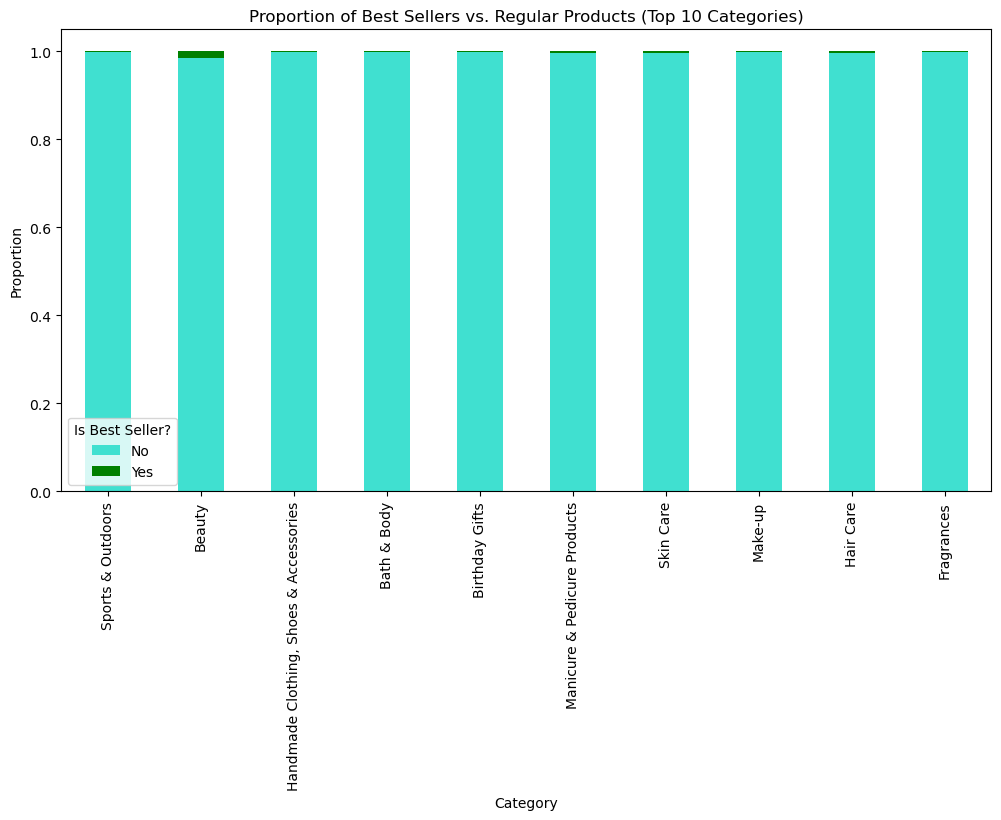

In [15]:
plot_data.plot(kind='bar', stacked=True, figsize=(12, 6), color=['turquoise', 'green'])

plt.title('Proportion of Best Sellers vs. Regular Products (Top 10 Categories)')
plt.xlabel('Category')
plt.ylabel('Proportion')
plt.legend(title='Is Best Seller?', labels=['No', 'Yes'])
plt.show()

In [17]:

# category_averages = df_clean.groupby('category')['price'].mean()

# expensive_category = category_averages.idxmax()
# highest_price_value = category_averages.max()
# print(f"The most expensive category is: {expensive_category}")
# print(f"The average price is: {highest_price_value:.2f}")